#### Imports

In [1]:
import numpy as np
import numba as nb
from numba.typed import List
import math
from time import perf_counter
import matplotlib.pyplot as plt

#### Function definitions

In [ ]:
LOG2 = math.log(2.0)


@nb.njit(fastmath=False, cache=True)
def get_grid(t):
    """
    Compute the grid Gt for a given time step t. Non-recursive version.

    Parameters
    ----------
    t : int

    Returns
    -------
    np.ndarray (int64)
        The grid Gt as an integer NumPy array.
    """
    if t <= 1:
        out = np.empty(1, dtype=np.int64)
        out[0] = 1
        return out

    # upper1 <- floor(log((t - 1) / 3, base = 2)) + 1
    # upper2 <- floor(log(t - 1, base = 2)) - 1
    upper1 = math.floor(math.log((t - 1) / 3.0) / LOG2) + 1
    upper2 = math.floor(math.log(t - 1) / LOG2) - 1

    # Preallocate output array
    length = 1 + (upper1 if upper1 > 0 else 0) + (upper2 if upper2 > 0 else 0)
    Gt = np.empty(length, dtype=np.int64)

    Gt[0] = 1
    counter = 1

    if upper1 >= 1:
        for j in range(1, upper1 + 1):
            # gL <- 2^j + (t - 1) %% 2^(j - 1)
            gL = (1 << j) + ((t - 1) % (1 << (j - 1)))
            Gt[counter] = gL
            counter += 1

            if j <= upper2:
                # Gt[counter] <- gL + 2^(j - 1)
                Gt[counter] = gL + (1 << (j - 1))
                counter += 1

    return Gt


@nb.njit(fastmath=False, cache=True)
def v2_numba(r: int) -> int:
    """
    Compute the exponent of the largest power of 2 that divides r.
    """
    if r == 0:
        return -1
    if r < 0:
        r = -r
    c = 0
    while (r & 1) == 0:
        c += 1
        r >>= 1
    return c


@nb.njit(fastmath=False, cache=True)
def log2_floor(x: int) -> float:
    if x <= 0:
        raise ValueError("x must be positive")
    n = 0
    v = x  # assume x is int64 and positive
    if v >= (1 << 32):
        v >>= 32
        n += 32
    if v >= (1 << 16):
        v >>= 16
        n += 16
    if v >= (1 << 8):
        v >>= 8
        n += 8
    if v >= (1 << 4):
        v >>= 4
        n += 4
    if v >= (1 << 2):
        v >>= 2
        n += 2
    if v >= (1 << 1):
        n += 1
    return n * 1.0


@nb.njit(fastmath=True, cache=True)
def fastlog(x):
    return math.log(x)


@nb.njit(fastmath=False, cache=True)
def update_grid(old_grid, t):
    """
    Update the grid old_grid in place to reflect the addition of a new data point at time t.
    Parameters
    ----------
    old_grid : List[int]
        The current grid to be updated.
    t : int
        The current (i.e., new) time step.
    """
    removed = -1
    removed_g = -1

    if t == 2 or t == 3:
        removed_g = old_grid[0]
        old_grid.pop(0)
        removed = 0
    elif t > 3:
        j = v2_numba(t - 1) + 1
        if j > 0:
            ind = 2 * j

            if ind < len(old_grid):
                removed = len(old_grid) - ind - 1
                removed_g = old_grid[removed]
                old_grid.pop(removed)

    old_grid.append(-t)

    return removed, removed_g


@nb.njit(fastmath=False, cache=True)
def update_data_grid(x_new, old_sums, old_S, t, removed):
    if removed >= 0:
        old_sums.pop(removed)
    old_sums.append(old_S)
    S = old_S + x_new
    return S


@nb.njit(fastmath=True, cache=True)
def update_full(x_new, sums, lam, t, s_size):
    alarm = False
    maxx = 0.0
    maxpos = -1

    new_s_size = s_size
    sums_new = None

    if t > s_size:
        new_s_size = 2 * new_s_size
        sums_new = np.zeros(new_s_size, dtype=np.int64)
        for i in range(t - 1):
            sums_new[i] = sums[i]
        sums_new[t - 1] = sums[-1] + x_new
    else:
        sums_new = sums
        sums_new[t - 1] = sums[t - 2] + x_new

    if t > 1:
        for j in range(t - 1):
            g = t - j - 1
            S0 = sums_new[t - 1]
            S1 = sums_new[j]
            S2 = S0 - S1
            term0 = 0
            if S0 > 0:
                term0 = S0 * fastlog(S0 / t)
            term1 = 0
            if S1 > 0:
                term1 = S1 * fastlog(S1 / (t - g))
            term2 = 0
            if S2 > 0:
                term2 = S2 * fastlog(S2 / g)

            LR = term1 + term2 - term0

            if LR > maxx:
                maxx = LR
                maxpos = j + 1
            if LR > lam:
                alarm = True

    return alarm, maxx, maxpos, sums_new, new_s_size


@nb.njit(fastmath=False, cache=True)
def update_grid_method(x_new, sums, S, lam, t, grid):
    removed, removed_g = update_grid(grid, t)
    S_new = update_data_grid(x_new, sums, S, t, removed)
    alarm = False
    maxx = 0.0
    maxpos = -1

    if t > 1:
        for j in range(len(grid) - 1, -1, -1):
            g = grid[j] + t + 1
            S0 = S_new
            S1 = sums[j]
            S2 = S0 - S1
            term0 = 0
            if S0 > 0:
                term0 = S0 * fastlog(S0 / t)
            term1 = 0
            if S1 > 0:
                term1 = S1 * fastlog(S1 / (t - g))
            term2 = 0
            if S2 > 0:
                term2 = S2 * fastlog(S2 / g)

            LR = term1 + term2 - term0

            if LR > maxx:
                maxx = LR
                maxpos = grid[j] + t + 1
            if LR > lam:
                alarm = True

    return alarm, maxx, maxpos, sums, S_new, grid


@nb.njit(fastmath=False, cache=True)
def train_full(N, K, seed):
    np.random.seed(seed)
    vals = np.zeros(K)
    for k in range(K):
        lam = 0.0
        t = 1

        s_size = 64
        sums = np.zeros(s_size, np.int64)
        x = np.random.poisson(lam=1.0, size=N)
        val = 0.0
        for i in range(N):
            t = i + 1
            alarm, maxx, maxpos, sums_new, new_s_size = update_full(
                x[i], sums, lam, t, s_size
            )
            s_size = new_s_size
            sums = sums_new
            if maxx > val:
                val = maxx
        vals[k] = val

    return vals


@nb.njit(fastmath=False, cache=True)
def train_grid(N, K, seed):
    np.random.seed(seed)
    vals = np.zeros(K)
    for k in range(K):
        S = 0
        lam = 0.0
        t = 1
        grid = List([0])
        grid.pop()

        sums = List([0])
        sums.pop()
        x = np.random.poisson(lam=1.0, size=N)
        val = 0.0
        for i in range(N):
            t = i + 1
            alarm, maxx, maxpos, sums, S, grid = update_grid_method(
                x[i], sums, S, lam, t, grid
            )
            if maxx > val:
                val = maxx
        vals[k] = val

    return vals


@nb.njit(fastmath=False, cache=True)
def run_simulation(
    sim, N, change_lower, change_upper, lambda2, lam_grid, lam_full, seed
):

    alarms_grid = np.ones(sim, dtype=np.int64) * N
    alarms_full = np.ones(sim, dtype=np.int64) * N
    changelocs = np.zeros(sim, dtype=np.int64)

    np.random.seed(seed)
    for k in range(sim):
        x = np.zeros(N, dtype=np.int64)
        changeloc = np.random.randint(change_lower, change_upper)
        changelocs[k] = changeloc
        x[:changeloc] = np.random.poisson(lam=1.0, size=changeloc)
        x[changeloc:] = np.random.poisson(lam=lambda2, size=N - changeloc)

        S = 0
        t = 1
        grid = List([0])
        grid.pop()

        sums = List([0])
        sums.pop()

        cusums = List([0.0])
        cusums.pop()

        s_size = 64
        sums_full = np.zeros(s_size, np.int64)

        for i in range(N):
            t = i + 1
            if alarms_grid[k] == N:
                alarm, maxx, maxpos, sums, S, grid = update_grid_method(
                    x[i], sums, S, lam_grid, t, grid
                )
                if alarm:
                    if alarms_grid[k] == N:
                        alarms_grid[k] = t

            if alarms_full[k] == N:
                alarm_full, maxx_full, maxpos_full, sums_new_full, new_s_size = (
                    update_full(x[i], sums_full, lam_full, t, s_size)
                )
                sums_full = sums_new_full
                s_size = new_s_size

                if alarm_full:
                    if alarms_full[k] == N:
                        alarms_full[k] = t

    return alarms_grid, alarms_full, changelocs

#### Test run!!

In [ ]:
np.random.seed(42)
N = 1000
changeloc = 500
x = np.zeros(N, dtype=np.int64)
x[:changeloc] = np.random.poisson(lam=1.0, size=changeloc)
x[changeloc:] = np.random.poisson(lam=2.0, size=N - changeloc)


S = 0
lam = 1000
lam_full = 1000
t = 1
grid = List([0])
grid.pop()

sums = List([0])
sums.pop()


s_size = 32
sums_full = np.zeros(s_size, dtype=np.int64)


for i in range(N):
    t = i + 1
    alarm, maxx, maxpos, sums, S, grid = update_grid_method(x[i], sums, S, lam, t, grid)
    if alarm:
        print(
            "Grid-based alarm at time ",
            t,
            " at position ",
            maxpos,
            " with value ",
            maxx,
        )

    alarm_full, maxx_full, maxpos_full, sums_full, s_size = update_full(
        x[i], sums_full, lam_full, t, s_size
    )
    if alarm_full:
        print(
            "Full-scan alarm at time ",
            t,
            " at position ",
            maxpos_full,
            " with value ",
            maxx_full,
        )

#### Simulation study

In [4]:
N = 10_000
K = 10_000
delta = 0.05
seed = 123412
_ = train_grid(1000, 1, seed)
_ = train_full(1000, 1, seed)

In [5]:
t0 = perf_counter()
sample_grid = train_grid(N, K, seed)
t_grid = perf_counter() - t0
print(f"Grid training time for N={N}, K={K}: {t_grid:.4f} seconds")

Grid training time for N=10000, K=10000: 54.6332 seconds


In [6]:
t0 = perf_counter()
sample_full = train_full(N, K, seed)
t_full = perf_counter() - t0
print(f"Full training time for N={N}, K={K}: {t_full:.4f} seconds")

Full training time for N=10000, K=10000: 3570.5598 seconds


In [7]:
lam_grid = np.quantile(sample_grid, 1 - delta)
lam_full = np.quantile(sample_full, 1 - delta)
print(lam_grid)
print(lam_full)

11.747446028051097
12.530396934148055


In [8]:
change_lower = N // 4
change_upper = N // 2
lambda2 = 10000
seed = 12345
sim = 40


alarms_grid, alarms_full, changeloc = run_simulation(
    sim, N, change_lower, change_upper, lambda2, lam_grid, lam_full, seed
)

In [9]:
changeloc

array([2982, 3320, 4243, 3713, 4138, 2787, 4663, 4565, 3939, 4314, 4793,
       2701, 4799, 2810, 3772, 3713, 4208, 3177, 3918, 4587, 3841, 2912,
       3923, 3838, 4192, 2902, 4665, 2529, 3295, 3181, 2883, 3222, 4708,
       4911, 2590, 4700, 4559, 2585, 3902, 4774])

In [ ]:
sim = 1000

change_lower = N // 4
change_upper = N // 2

lambda2s = np.arange(0.0, 5.0, 0.1)

seed = 12345

dds_grid = np.zeros(len(lambda2s))
dds_full = np.zeros(len(lambda2s))

for i in range(len(lambda2s)):
    if i % 5 == 0:
        print("lambda2 =", lambda2s[i])
    alarms_grid, alarms_full, changeloc = run_simulation(
        sim,
        N,
        change_lower,
        change_upper,
        lambda2s[i],
        lam_grid,
        lam_full,
        seed,
    )
    dds_grid[i] = np.mean(
        alarms_grid[alarms_grid >= changeloc] - changeloc[alarms_grid >= changeloc]
    )
    dds_full[i] = np.mean(
        alarms_full[alarms_full >= changeloc] - changeloc[alarms_full >= changeloc]
    )

lambda2 = 0.0
lambda2 = 0.5
lambda2 = 1.0
lambda2 = 1.5
lambda2 = 2.0
lambda2 = 2.5
lambda2 = 3.0
lambda2 = 3.5
lambda2 = 4.0
lambda2 = 4.5


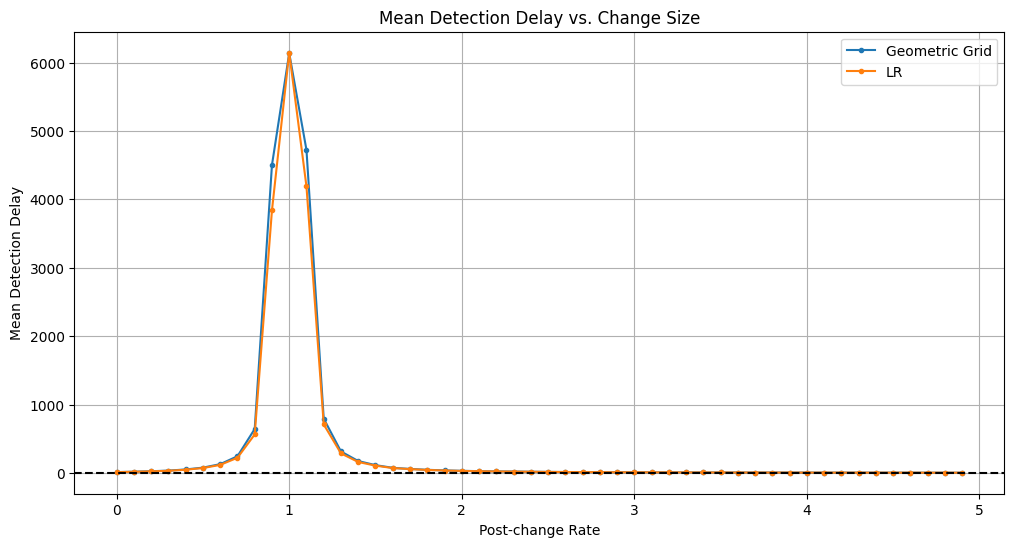

In [13]:
# plot the results
plt.figure(figsize=(12, 6))
plt.plot(lambda2s, dds_grid, label="Geometric Grid", marker="o", markersize=3)
plt.plot(lambda2s, dds_full, label="LR", marker="o", markersize=3)
plt.axhline(y=0, color="k", linestyle="--")
plt.title("Mean Detection Delay vs. Change Size")
plt.xlabel("Post-change Rate")
plt.ylabel("Mean Detection Delay")
plt.legend()
plt.grid()
plt.savefig("dd_full_vs_grid_poisson.pdf")
plt.show()

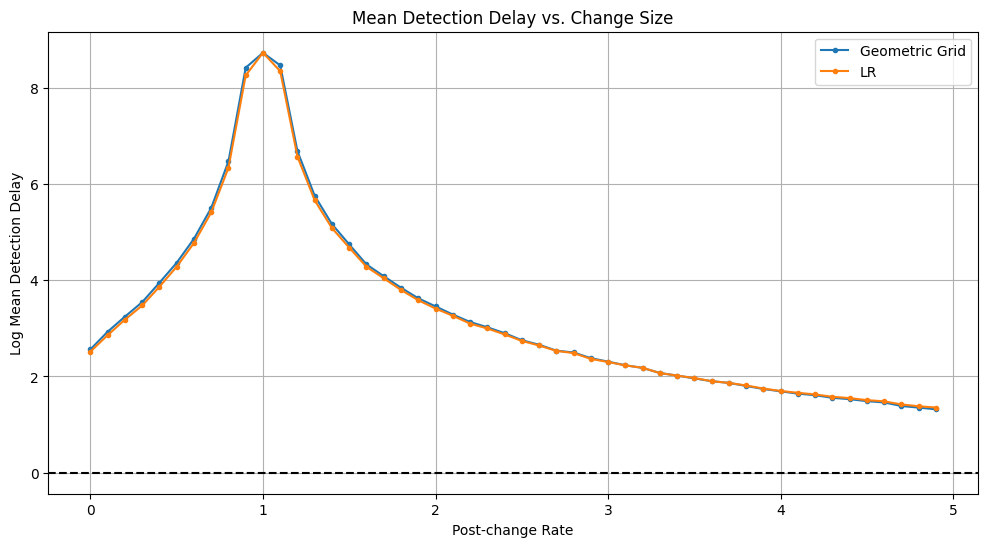

In [14]:
# plot the results
plt.figure(figsize=(12, 6))
plt.plot(lambda2s, np.log(dds_grid), label="Geometric Grid", marker="o", markersize=3)
plt.plot(lambda2s, np.log(dds_full), label="LR", marker="o", markersize=3)
plt.axhline(y=0, color="k", linestyle="--")
plt.title("Mean Detection Delay vs. Change Size")
plt.xlabel("Post-change Rate")
plt.ylabel("Log Mean Detection Delay")
plt.legend()
plt.grid()
plt.savefig("dd_full_vs_grid_poisson_log.pdf")
plt.show()